# False discovery rate p-value correction.

### SciPy
I am going to use https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.false_discovery_control.html
It states the parameters:
- ps: 1D array like (the p-vaues to adjust)
- axis: if none, ps is aveled before performing the adjustment
- method: there are two methods
	- 'bh' = Benjamini-Hochberg (for independent or positively dependent)
	- 'by' = Benjaminini-Yekutieli (Controls the FDR under any dependency structure, including arbitrary dependence among the tests).

The tests are not independent so the corrected p-value will be the most conservative one (Bonferroni).
- Add a soft threshold with FDR and then a stronger confirmation with Bonferroni. 

In [1]:
import os
import yaml
import argparse
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
#pip install statsmodels
import statsmodels.stats.multitest as smm
from statsmodels.stats.multitest import multipletests

In [2]:
# ldsc_results = pd.read_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation.csv")
# ldsc_results = pd.read_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation_MN.csv")
# ldsc_results = pd.read_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation_v2_filled_in.csv")
ldsc_results = pd.read_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation_MN2OCT.csv")


In [3]:
display(ldsc_results)

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.051700,-0.2519,8.011000e-01,0.0317,0.0044,1.0620,0.0172,0.000400,0.0057
1,GCST009979,mdd-1,GCST90129443,headache-disorder-2,0.4217,0.038800,10.8742,1.529800e-27,0.0393,0.0026,1.0557,0.0102,0.052500,0.0061
2,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.150000,0.5509,5.817000e-01,0.0180,0.0029,1.0300,0.0107,-0.002800,0.0045
3,GCST009315,PTSD-PGC-2019,GCST90435631,lymph-node-malignant-neoplasm,-0.0140,0.171500,-0.0813,9.352000e-01,0.0043,0.0011,0.9990,0.0063,-0.001400,0.0050
4,GCST90137411,bcc-2,GCST90137411,bcc-2,1.0000,0.000002,453429.6142,0.000000e+00,0.0697,0.0121,0.9758,0.0235,0.975800,0.0235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7764,GCST90041833,breast-neoplasm-2,GCST90271619,partial-epilepsy-2,-0.2053,0.141900,-1.4469,1.479000e-01,0.0469,0.0112,1.0244,0.0085,0.005600,0.0072
7765,GCST009979,mdd-1,GCST90435597,skin-neoplasm,-0.0364,0.058600,-0.6212,5.345000e-01,0.0171,0.0030,1.0291,0.0137,0.000094,0.0055
7766,GCST90239856,uterine-leiomyoma-2,GCST90239856,uterine-leiomyoma-2,1.0001,0.000031,32180.8494,0.000000e+00,0.0250,0.0027,1.0302,0.0120,1.030200,0.0120
7767,GCST004744,adenocarcinoma-lung,GCST004692,lateral-sclerosis-2,0.2197,0.138500,1.5864,1.127000e-01,0.0385,0.0119,1.0012,0.0068,0.016100,0.0048


In [4]:
### TEST BONFERRONI 1
reject_bonf, corrected_p_vals, _, _ = smm.multipletests(ldsc_results['p'], method='bonferroni')

# Replace original 'p' column with corrected p-values
ldsc_results['p_corrected_M1'] = corrected_p_vals
ldsc_results['p_bonf_rejected'] = reject_bonf

In [5]:
### TEST BONFERRONI 2
m = len(ldsc_results)

# Bonferroni corrected p-values
ldsc_results['p_corrected_M2'] = ldsc_results['p'] * m

In [6]:
display(ldsc_results)

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.051700,-0.2519,8.011000e-01,0.0317,0.0044,1.0620,0.0172,0.000400,0.0057,1.000000e+00,False,6.223746e+03
1,GCST009979,mdd-1,GCST90129443,headache-disorder-2,0.4217,0.038800,10.8742,1.529800e-27,0.0393,0.0026,1.0557,0.0102,0.052500,0.0061,1.188502e-23,True,1.188502e-23
2,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.150000,0.5509,5.817000e-01,0.0180,0.0029,1.0300,0.0107,-0.002800,0.0045,1.000000e+00,False,4.519227e+03
3,GCST009315,PTSD-PGC-2019,GCST90435631,lymph-node-malignant-neoplasm,-0.0140,0.171500,-0.0813,9.352000e-01,0.0043,0.0011,0.9990,0.0063,-0.001400,0.0050,1.000000e+00,False,7.265569e+03
4,GCST90137411,bcc-2,GCST90137411,bcc-2,1.0000,0.000002,453429.6142,0.000000e+00,0.0697,0.0121,0.9758,0.0235,0.975800,0.0235,0.000000e+00,True,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7764,GCST90041833,breast-neoplasm-2,GCST90271619,partial-epilepsy-2,-0.2053,0.141900,-1.4469,1.479000e-01,0.0469,0.0112,1.0244,0.0085,0.005600,0.0072,1.000000e+00,False,1.149035e+03
7765,GCST009979,mdd-1,GCST90435597,skin-neoplasm,-0.0364,0.058600,-0.6212,5.345000e-01,0.0171,0.0030,1.0291,0.0137,0.000094,0.0055,1.000000e+00,False,4.152530e+03
7766,GCST90239856,uterine-leiomyoma-2,GCST90239856,uterine-leiomyoma-2,1.0001,0.000031,32180.8494,0.000000e+00,0.0250,0.0027,1.0302,0.0120,1.030200,0.0120,0.000000e+00,True,0.000000e+00
7767,GCST004744,adenocarcinoma-lung,GCST004692,lateral-sclerosis-2,0.2197,0.138500,1.5864,1.127000e-01,0.0385,0.0119,1.0012,0.0068,0.016100,0.0048,1.000000e+00,False,8.755663e+02


In [7]:
# Assuming ldsc_results is a pandas DataFrame
mask = (ldsc_results["p"] >= 0) & (ldsc_results["p"] <= 1)

# Extract valid rows
valid_data = ldsc_results[mask]

# Extract outliers (rows not in the mask)
outliers = ldsc_results[~mask]

display(outliers)

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2
151,GCST90435601,breast-cancer-2,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
200,GCST90012878,alzheimers-disease-family-history,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
297,GCST90435857,mood-disorder,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
525,GCST90435919,headache-disorder-1,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
882,GCST90435926,epilepsy-1,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
1161,GCST003769,depression-symptoms,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
1727,GCST90435667,uterine-leiomyoma,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
1887,GCST008465,ANN-PGC-2019,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
2114,GCST90435594,skin-cancer,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
2136,GCST005903,mdd-2,GCST90428116,breast-cancer-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN


In [8]:
ldsc_results = ldsc_results[(ldsc_results["p"] >= 0) & (ldsc_results["p"] <= 1)]
display(ldsc_results)

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.051700,-0.2519,8.011000e-01,0.0317,0.0044,1.0620,0.0172,0.000400,0.0057,1.000000e+00,False,6.223746e+03
1,GCST009979,mdd-1,GCST90129443,headache-disorder-2,0.4217,0.038800,10.8742,1.529800e-27,0.0393,0.0026,1.0557,0.0102,0.052500,0.0061,1.188502e-23,True,1.188502e-23
2,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.150000,0.5509,5.817000e-01,0.0180,0.0029,1.0300,0.0107,-0.002800,0.0045,1.000000e+00,False,4.519227e+03
3,GCST009315,PTSD-PGC-2019,GCST90435631,lymph-node-malignant-neoplasm,-0.0140,0.171500,-0.0813,9.352000e-01,0.0043,0.0011,0.9990,0.0063,-0.001400,0.0050,1.000000e+00,False,7.265569e+03
4,GCST90137411,bcc-2,GCST90137411,bcc-2,1.0000,0.000002,453429.6142,0.000000e+00,0.0697,0.0121,0.9758,0.0235,0.975800,0.0235,0.000000e+00,True,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7764,GCST90041833,breast-neoplasm-2,GCST90271619,partial-epilepsy-2,-0.2053,0.141900,-1.4469,1.479000e-01,0.0469,0.0112,1.0244,0.0085,0.005600,0.0072,1.000000e+00,False,1.149035e+03
7765,GCST009979,mdd-1,GCST90435597,skin-neoplasm,-0.0364,0.058600,-0.6212,5.345000e-01,0.0171,0.0030,1.0291,0.0137,0.000094,0.0055,1.000000e+00,False,4.152530e+03
7766,GCST90239856,uterine-leiomyoma-2,GCST90239856,uterine-leiomyoma-2,1.0001,0.000031,32180.8494,0.000000e+00,0.0250,0.0027,1.0302,0.0120,1.030200,0.0120,0.000000e+00,True,0.000000e+00
7767,GCST004744,adenocarcinoma-lung,GCST004692,lateral-sclerosis-2,0.2197,0.138500,1.5864,1.127000e-01,0.0385,0.0119,1.0012,0.0068,0.016100,0.0048,1.000000e+00,False,8.755663e+02


In [9]:
# Perform Benjamini-Yekutieli correction
ldsc_results['adjusted_p_by'] = stats.false_discovery_control(ldsc_results["p"].values, method='by')

# Perform Benjamini-Hochberg correction
ldsc_results['adjusted_p_bh'] = stats.false_discovery_control(ldsc_results["p"].values, method='bh')

# adjusted_p_values_by
display(ldsc_results.head())

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2,adjusted_p_by,adjusted_p_bh
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.051700,-0.2519,8.011000e-01,0.0317,0.0044,1.0620,0.0172,0.0004,0.0057,1.000000e+00,False,6.223746e+03,1.000000e+00,9.177576e-01
1,GCST009979,mdd-1,GCST90129443,headache-disorder-2,0.4217,0.038800,10.8742,1.529800e-27,0.0393,0.0026,1.0557,0.0102,0.0525,0.0061,1.188502e-23,True,1.188502e-23,2.553358e-25,2.678881e-26
2,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.150000,0.5509,5.817000e-01,0.0180,0.0029,1.0300,0.0107,-0.0028,0.0045,1.000000e+00,False,4.519227e+03,1.000000e+00,7.865733e-01
3,GCST009315,PTSD-PGC-2019,GCST90435631,lymph-node-malignant-neoplasm,-0.0140,0.171500,-0.0813,9.352000e-01,0.0043,0.0011,0.9990,0.0063,-0.0014,0.0050,1.000000e+00,False,7.265569e+03,1.000000e+00,9.746898e-01
4,GCST90137411,bcc-2,GCST90137411,bcc-2,1.0000,0.000002,453429.6142,0.000000e+00,0.0697,0.0121,0.9758,0.0235,0.9758,0.0235,0.000000e+00,True,0.000000e+00,0.000000e+00,0.000000e+00


In [10]:
pcorrectedvalue = (0.05/len(ldsc_results))
print(pcorrectedvalue)

6.459948320413437e-06


### Plot differences between p values and corrected p-values

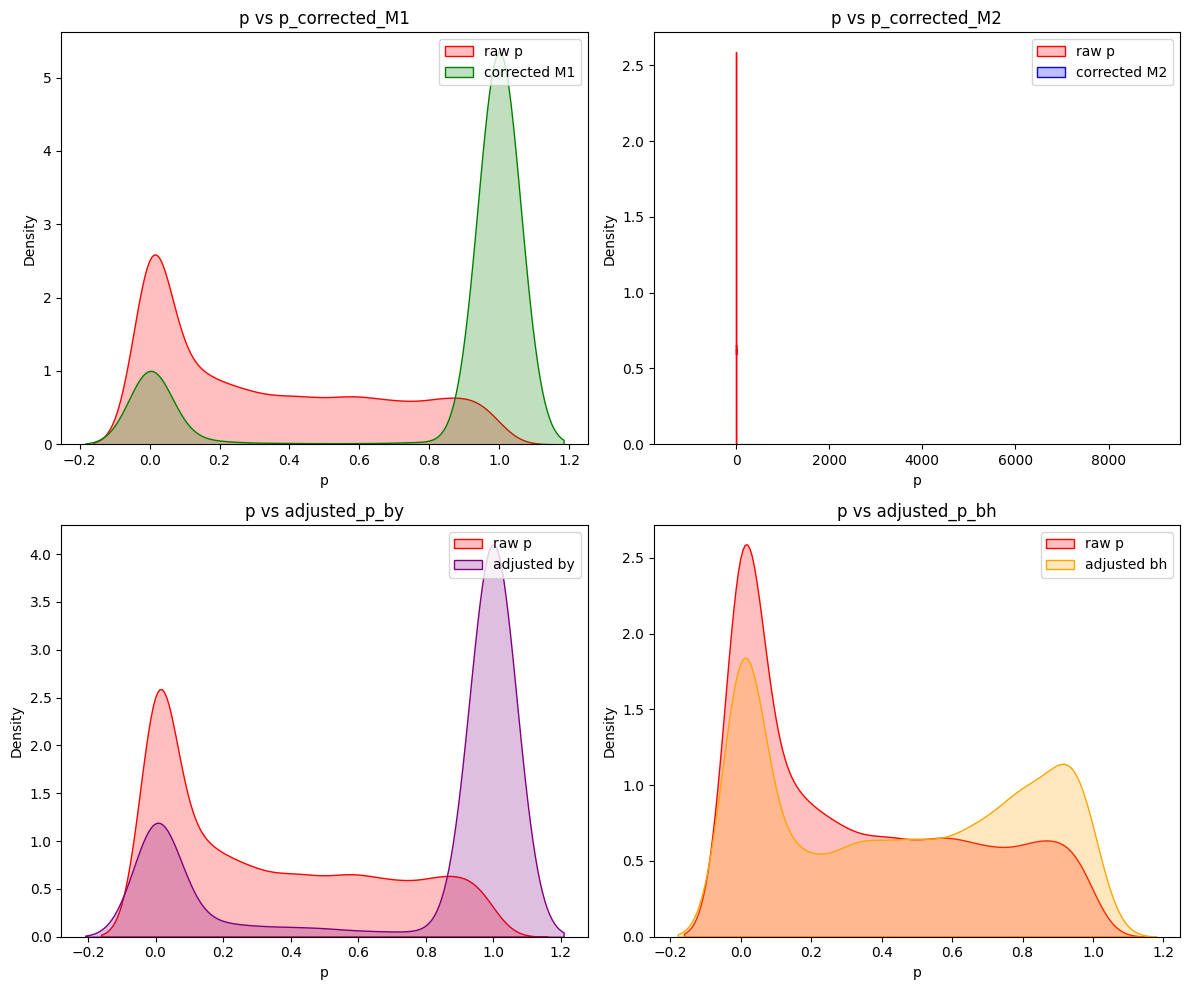

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# p vs p_corrected_M1
sns.kdeplot(ldsc_results['p'], color="red", fill=True, label='raw p', ax=axes[0, 0])
sns.kdeplot(ldsc_results['p_corrected_M1'], color="green", fill=True, label='corrected M1', ax=axes[0, 0])
axes[0, 0].set_title('p vs p_corrected_M1')
axes[0, 0].legend()

# p vs p_corrected_M2
sns.kdeplot(ldsc_results['p'], color="red", fill=True, label='raw p', ax=axes[0, 1])
sns.kdeplot(ldsc_results['p_corrected_M2'], color="blue", fill=True, label='corrected M2', ax=axes[0, 1])
axes[0, 1].set_title('p vs p_corrected_M2')
axes[0, 1].legend()

# p vs adjusted_p_by
sns.kdeplot(ldsc_results['p'], color="red", fill=True, label='raw p', ax=axes[1, 0])
sns.kdeplot(ldsc_results['adjusted_p_by'], color="purple", fill=True, label='adjusted by', ax=axes[1, 0])
axes[1, 0].set_title('p vs adjusted_p_by')
axes[1, 0].legend()

# p vs adjusted_p_bh
sns.kdeplot(ldsc_results['p'], color="red", fill=True, label='raw p', ax=axes[1, 1])
sns.kdeplot(ldsc_results['adjusted_p_bh'], color="orange", fill=True, label='adjusted bh', ax=axes[1, 1])
axes[1, 1].set_title('p vs adjusted_p_bh')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

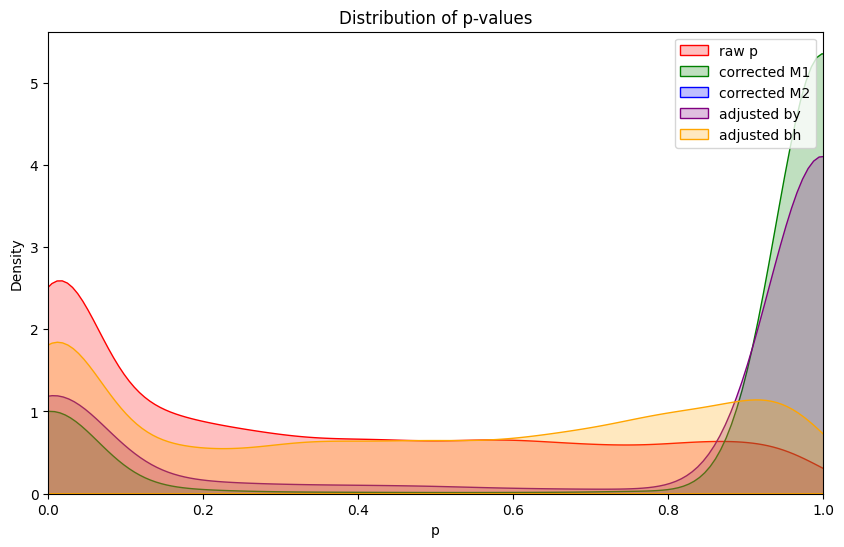

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(ldsc_results['p'], color="red", fill=True, label='raw p')
sns.kdeplot(ldsc_results['p_corrected_M1'], color="green", fill=True, label='corrected M1')
sns.kdeplot(ldsc_results['p_corrected_M2'], color="blue", fill=True, label='corrected M2')
sns.kdeplot(ldsc_results['adjusted_p_by'], color="purple", fill=True, label='adjusted by')
sns.kdeplot(ldsc_results['adjusted_p_bh'], color="orange", fill=True, label='adjusted bh')

plt.xlim(0, 1)
plt.title('Distribution of p-values')
plt.legend()
plt.show()

In [13]:
display(ldsc_results)

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2,adjusted_p_by,adjusted_p_bh
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.051700,-0.2519,8.011000e-01,0.0317,0.0044,1.0620,0.0172,0.000400,0.0057,1.000000e+00,False,6.223746e+03,1.000000e+00,9.177576e-01
1,GCST009979,mdd-1,GCST90129443,headache-disorder-2,0.4217,0.038800,10.8742,1.529800e-27,0.0393,0.0026,1.0557,0.0102,0.052500,0.0061,1.188502e-23,True,1.188502e-23,2.553358e-25,2.678881e-26
2,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.150000,0.5509,5.817000e-01,0.0180,0.0029,1.0300,0.0107,-0.002800,0.0045,1.000000e+00,False,4.519227e+03,1.000000e+00,7.865733e-01
3,GCST009315,PTSD-PGC-2019,GCST90435631,lymph-node-malignant-neoplasm,-0.0140,0.171500,-0.0813,9.352000e-01,0.0043,0.0011,0.9990,0.0063,-0.001400,0.0050,1.000000e+00,False,7.265569e+03,1.000000e+00,9.746898e-01
4,GCST90137411,bcc-2,GCST90137411,bcc-2,1.0000,0.000002,453429.6142,0.000000e+00,0.0697,0.0121,0.9758,0.0235,0.975800,0.0235,0.000000e+00,True,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7764,GCST90041833,breast-neoplasm-2,GCST90271619,partial-epilepsy-2,-0.2053,0.141900,-1.4469,1.479000e-01,0.0469,0.0112,1.0244,0.0085,0.005600,0.0072,1.000000e+00,False,1.149035e+03,1.000000e+00,3.439742e-01
7765,GCST009979,mdd-1,GCST90435597,skin-neoplasm,-0.0364,0.058600,-0.6212,5.345000e-01,0.0171,0.0030,1.0291,0.0137,0.000094,0.0055,1.000000e+00,False,4.152530e+03,1.000000e+00,7.556253e-01
7766,GCST90239856,uterine-leiomyoma-2,GCST90239856,uterine-leiomyoma-2,1.0001,0.000031,32180.8494,0.000000e+00,0.0250,0.0027,1.0302,0.0120,1.030200,0.0120,0.000000e+00,True,0.000000e+00,0.000000e+00,0.000000e+00
7767,GCST004744,adenocarcinoma-lung,GCST004692,lateral-sclerosis-2,0.2197,0.138500,1.5864,1.127000e-01,0.0385,0.0119,1.0012,0.0068,0.016100,0.0048,1.000000e+00,False,8.755663e+02,1.000000e+00,2.879822e-01


In [14]:
#Save the DataFrame with adjusted values back to a new CSV file
# ldsc_results.to_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation_corrected_11S.csv", index=False)